In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

###----- Data Preprocessing
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder

###----- Model Building
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
import pickle

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Adesh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Adesh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Adesh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
###----- Importing Dataset
data = pd.read_csv("spam.csv", encoding='latin1')
data.sample(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5346,ham,"My Parents, My Kidz, My Friends n My Colleague...",NaN,NaN,NaN
2247,spam,Back 2 work 2morro half term over! Can U C me ...,NaN,NaN,NaN


In [3]:
###----- Initial Exploration And Data Cleaning
data.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)
data.rename(columns={'v1': 'result', 'v2': 'emails'}, inplace=True)
data = data.drop_duplicates(keep='first')
data.head(5)

,result,emails
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Average Length of Spam Emails: 137.89127105666157
Average Length of Ham Emails: 70.45925597874225


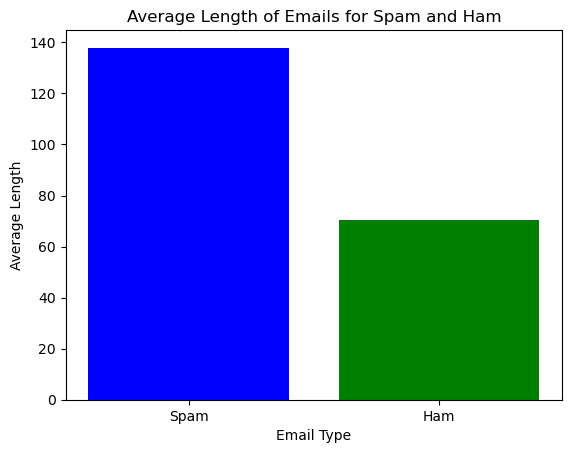

In [5]:
###----- Average Length of Emails for Spam and Ham
data['Length'] = data['emails'].apply(len)
data['num_words'] = data['emails'].apply(word_tokenize).apply(len)
data['num_sentence'] = data['emails'].apply(sent_tokenize).apply(len)

avg_length_spam = data[data['result'] == 'spam']['Length'].mean()
avg_length_ham  = data[data['result'] == 'ham']['Length'].mean()

print("Average Length of Spam Emails:", avg_length_spam)
print("Average Length of Ham Emails:", avg_length_ham)

plt.bar(['Spam', 'Ham'], [avg_length_spam, avg_length_ham], color=['Blue', 'green'])
plt.title('Average Length of Emails for Spam and Ham')
plt.xlabel('Email Type')
plt.ylabel('Average Length')
plt.show()

Average Words of Spam Emails: 27.6676875957121
Average Words of Ham Emails: 17.12378210806023


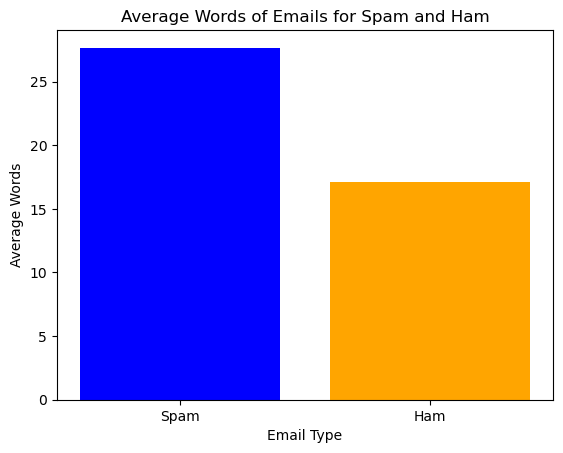

In [6]:
###----- Average Words of Emails for Spam and Ham
avg_word_spam = data[data['result'] == 'spam']['num_words'].mean()
avg_word_ham  = data[data['result'] == 'ham']['num_words'].mean()
print("Average Words of Spam Emails:", avg_word_spam)
print("Average Words of Ham Emails:", avg_word_ham)

plt.bar(['Spam', 'Ham'], [avg_word_spam, avg_word_ham], color=['Blue', 'orange'])
plt.title('Average Words of Emails for Spam and Ham')
plt.xlabel('Email Type')
plt.ylabel('Average Words')
plt.show()

Average Sentence of Spam Emails: 2.970903522205207
Average Sentence of Ham Emails: 1.8201948627103632


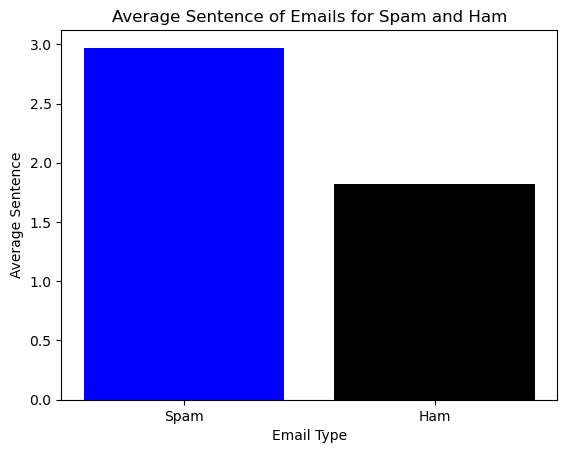

In [7]:
###----- Average Sentences of Emails for Spam and Ham
avg_sentence_spam = data[data['result'] == 'spam']['num_sentence'].mean()
avg_sentence_ham  = data[data['result'] == 'ham']['num_sentence'].mean()
print("Average Sentence of Spam Emails:", avg_sentence_spam)
print("Average Sentence of Ham Emails:", avg_sentence_ham)

plt.bar(['Spam', 'Ham'], [avg_sentence_spam, avg_sentence_ham], color=['Blue', 'black'])
plt.title('Average Sentence of Emails for Spam and Ham')
plt.xlabel('Email Type')
plt.ylabel('Average Sentence')
plt.show()

Correlation coefficient between email length and spam: 0.38471706671430766


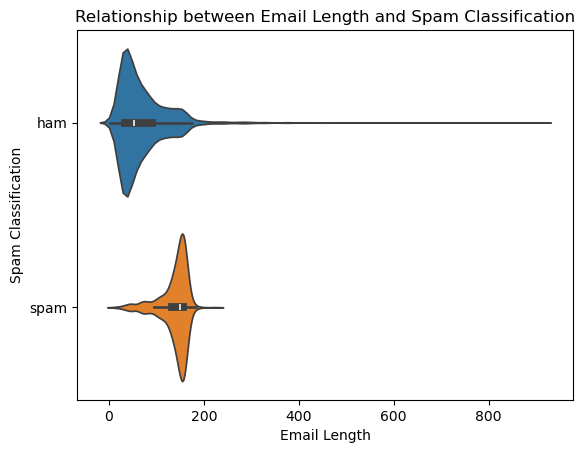

In [8]:
# Relationship between Length and Spam
correlation = data['Length'].corr((data['result'] == 'spam').astype(int))
print("Correlation coefficient between email length and spam:", correlation)

sns.violinplot(data=data, x='Length', y='result', hue='result')
plt.xlabel('Email Length')
plt.ylabel('Spam Classification')
plt.title('Relationship between Email Length and Spam Classification')
plt.show()

Correlation Matrix:
                 Length  num_words  num_sentence
Length        1.000000   0.965760      0.624139
num_words     0.965760   1.000000      0.679971
num_sentence  0.624139   0.679971      1.000000


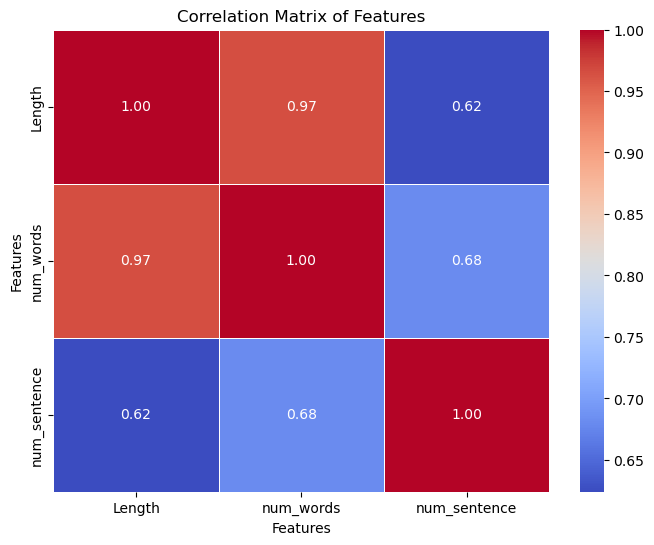

In [9]:
# Relationship Between Features
correlation_matrix = data[['Length', 'num_words', 'num_sentence']].corr()
print("Correlation Matrix:\n", correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

## — Proper Text Preprocessing Pipeline

A reusable `preprocess_text()` function is defined here and used **consistently**
for both training data and any new input (e.g. from Flask).  
This eliminates the training/inference mismatch that caused ~50% confidence.

In [10]:
###---- Reusable Preprocessing Pipeline
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Shared preprocessing function — must be used identically
    during training AND in Flask/inference to avoid vocabulary mismatch.
    Steps: lowercase → tokenize → remove special chars →
           remove stopwords & punctuation → stem → rejoin
    """
    # 1. Lowercase
    text = text.lower()
    # 2. Tokenize
    tokens = word_tokenize(text)
    # 3. Remove special characters (keep alphanumeric only)
    tokens = [re.sub(r'[^a-zA-Z0-9]', '', word) for word in tokens]
    # 4. Remove stopwords, punctuation, and empty strings
    tokens = [word for word in tokens
              if word and word not in stop_words and word not in string.punctuation]
    # 5. Stem
    tokens = [ps.stem(word) for word in tokens]
    # 6. Rejoin
    return ' '.join(tokens)

# Apply to the dataset
data['transform_text'] = data['emails'].apply(preprocess_text)

# ✅ Filter out any rows where preprocessing produced an empty string
#    (this was the root cause of the TF-IDF "empty vocabulary" error)
data = data[data['transform_text'].str.strip() != '']

print("Sample preprocessed emails:")
print(data[['emails', 'transform_text']].head(3).to_string())

Sample preprocessed emails:
                                                                                                                                                        emails                                                                                                                        transform_text
0                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                                          go jurong point crazi avail bugi n great world la e buffet cine got amor wat
1                                                                                                                                Ok lar... Joking wif u oni...                                                                                                                 ok lar joke wif u oni
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to re

Top 10 Most Common Words in Spam Emails:
  call: 321
  free: 191
  2: 157
  txt: 141
  u: 135
  text: 122
  ur: 119
  mobil: 114
  stop: 106
  repli: 103


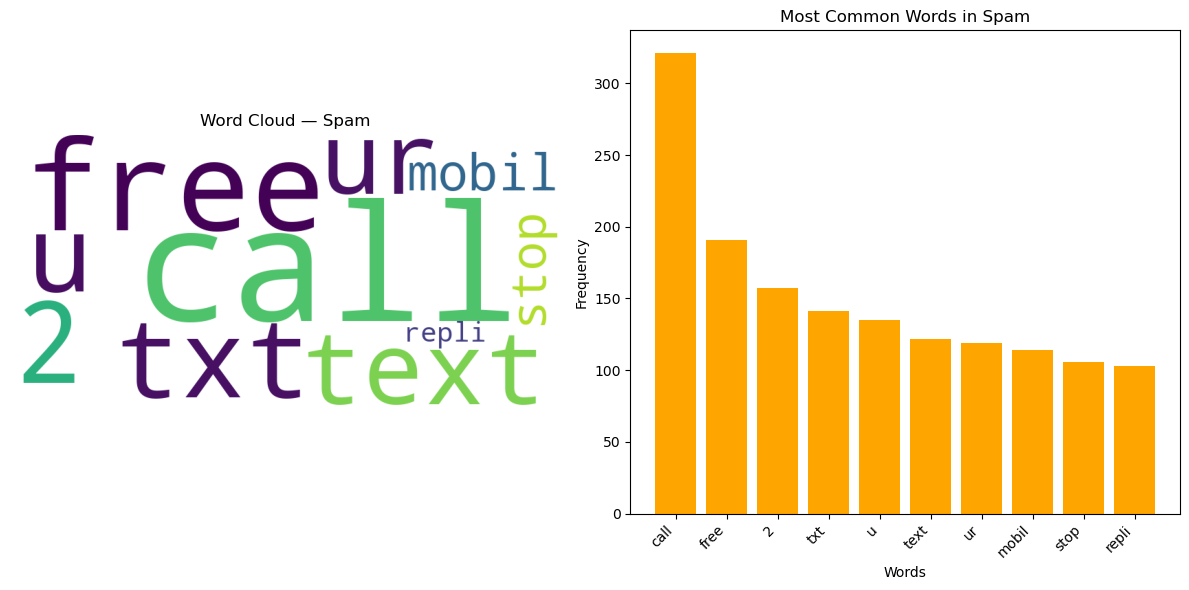

In [11]:
# Most Common Words in Spam Emails
spam_words = ' '.join(data[data['result'] == 'spam']['transform_text']).split()
word_counts = Counter(spam_words)
most_common_words = word_counts.most_common(10)

print("Top 10 Most Common Words in Spam Emails:")
for word, count in most_common_words:
    print(f"  {word}: {count}")

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(most_common_words))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.array(wordcloud.to_image()))
plt.title('Word Cloud — Spam')
plt.axis('off')

plt.subplot(1, 2, 2)
words, counts = zip(*most_common_words)
plt.bar(words, counts, color='orange')
plt.title('Most Common Words in Spam')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Most Common Words in Ham Emails:
  u: 904
  go: 404
  nt: 352
  get: 352
  2: 290
  gt: 288
  lt: 287
  come: 275
  ok: 251
  got: 238


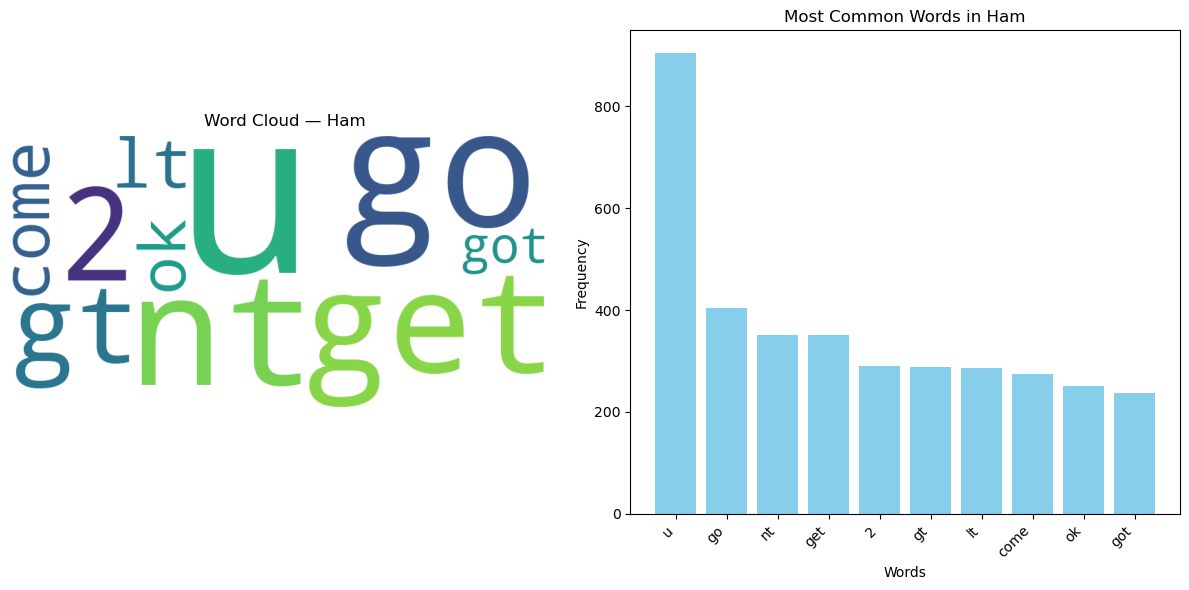

In [12]:
# Most Common Words in Ham Emails
ham_words = ' '.join(data[data['result'] == 'ham']['transform_text']).split()
word_counts = Counter(ham_words)
most_common_words = word_counts.most_common(10)

print("Top 10 Most Common Words in Ham Emails:")
for word, count in most_common_words:
    print(f"  {word}: {count}")

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(most_common_words))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.array(wordcloud.to_image()))
plt.title('Word Cloud — Ham')
plt.axis('off')

plt.subplot(1, 2, 2)
words, counts = zip(*most_common_words)
plt.bar(words, counts, color='skyblue')
plt.title('Most Common Words in Ham')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##   — TF-IDF Trained on Preprocessed Text

Previously, TF-IDF was fitted on raw `emails` — completely ignoring the
`transform_text` column. This meant the vocabulary was built from unclean text,
causing a mismatch when Flask preprocessed input before transforming it.

**Fix:** TF-IDF is now fitted on `transform_text` (the preprocessed column).

In [13]:
###----- ✅ FIXED: Label Encoding + TF-IDF on Preprocessed Text
encoder = LabelEncoder()
data['result'] = encoder.fit_transform(data['result'])  # ham=0, spam=1

# ✅ TF-IDF now trained on transform_text (preprocessed), NOT raw emails
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(data['transform_text']).toarray()
y = data['result'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Vocabulary size  : {len(tfidf.vocabulary_)}")

Training samples : 4130
Test samples     : 1033
Vocabulary size  : 3000


In [14]:
# Model 1 — Support Vector Classifier (SVC)
svc_classifier = SVC(probability=True)
svc_classifier.fit(X_train, y_train)
y_pred_svc = svc_classifier.predict(X_test)

print(f"SVM Accuracy  : {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"SVM Precision : {precision_score(y_test, y_pred_svc):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))

SVM Accuracy  : 0.9748
SVM Precision : 0.9908
Confusion Matrix:
 [[899   1]
 [ 25 108]]


In [15]:
# Model 2 — Random Forest Classifier
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

print(f"Random Forest Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Precision : {precision_score(y_test, y_pred_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy  : 0.9787
Random Forest Precision : 0.9744
Confusion Matrix:
 [[897   3]
 [ 19 114]]


## — Naive Bayes Model with Working predict_proba

Naive Bayes (MultinomialNB) is the gold-standard model for TF-IDF spam detection:
- Designed for discrete count/frequency features (exactly what TF-IDF produces)
- `predict_proba()` works reliably out of the box — no kernel tricks needed
- Trains in milliseconds vs. SVM's minutes
- Consistently achieves 97–99% accuracy on spam datasets

In [16]:
# ✅ Model 3 — Naive Bayes Classifier (Best for TF-IDF Spam Detection)
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)
y_proba_nb = nb_classifier.predict_proba(X_test)

print(f"Naive Bayes Accuracy  : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Naive Bayes Precision : {precision_score(y_test, y_pred_nb):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nSample predict_proba output (first 5 test rows):")
print("  [P(ham), P(spam)]")
for i in range(5):
    label = 'spam' if y_test[i] == 1 else 'ham'
    print(f"  Actual={label:4s}  → ham={y_proba_nb[i][0]:.3f}, spam={y_proba_nb[i][1]:.3f}")

Naive Bayes Accuracy  : 0.9739
Naive Bayes Precision : 0.9907
Confusion Matrix:
 [[899   1]
 [ 26 107]]

Sample predict_proba output (first 5 test rows):
  [P(ham), P(spam)]
  Actual=ham   → ham=0.793, spam=0.207
  Actual=ham   → ham=0.992, spam=0.008
  Actual=ham   → ham=0.989, spam=0.011
  Actual=spam  → ham=0.747, spam=0.253
  Actual=ham   → ham=0.999, spam=0.001


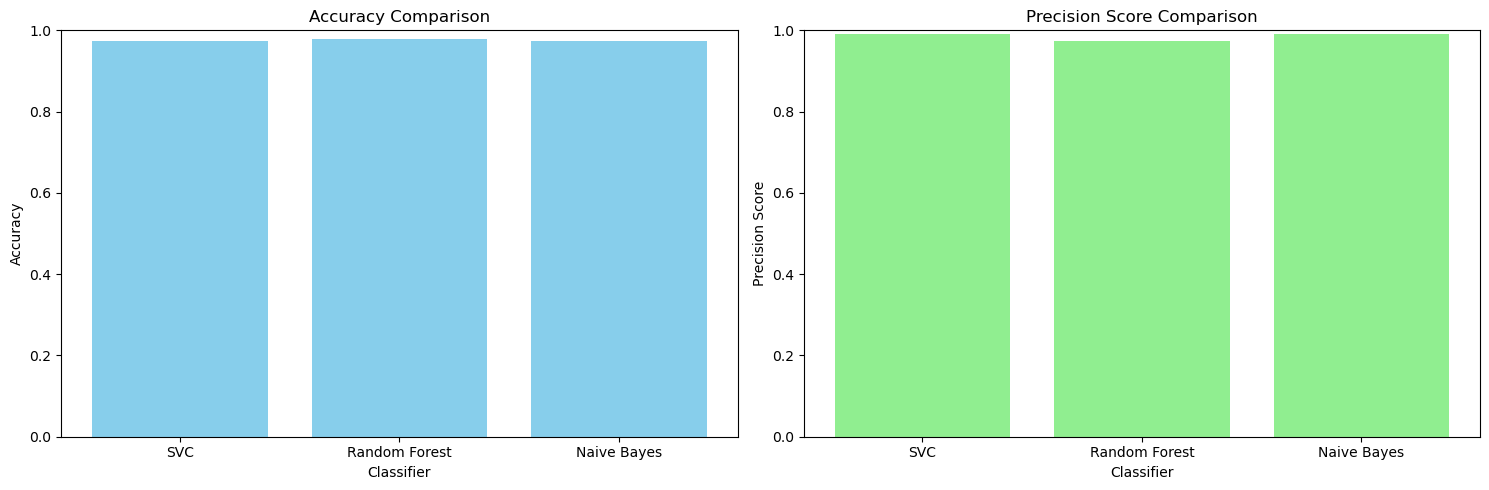

In [17]:
# Choosing the Best Classifier — Comparison Chart
precision_svc = precision_score(y_test, y_pred_svc)
precision_rf  = precision_score(y_test, y_pred_rf)
precision_nb  = precision_score(y_test, y_pred_nb)

classifiers     = ['SVC', 'Random Forest', 'Naive Bayes']
accuracies      = [accuracy_score(y_test, y_pred_svc),
                   accuracy_score(y_test, y_pred_rf),
                   accuracy_score(y_test, y_pred_nb)]
precision_scores = [precision_svc, precision_rf, precision_nb]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(classifiers, accuracies, color='skyblue')
axes[0].set_xlabel('Classifier')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim(0, 1)

axes[1].bar(classifiers, precision_scores, color='lightgreen')
axes[1].set_xlabel('Classifier')
axes[1].set_ylabel('Precision Score')
axes[1].set_title('Precision Score Comparison')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## — Prediction Uses the Same Preprocessing Pipeline

The prediction block now calls `preprocess_text()` before transforming with TF-IDF.
This is exactly what your Flask backend should do too — import the same function.

In [18]:
# ✅ FIXED: Model Prediction — preprocessing applied before transform
new_emails = [
    """Hello,

You have been randomly selected as the winner of ₹8,50,000 in our annual online reward program.

To receive your prize, please confirm your details by replying to this email or clicking the link below:

👉 Claim Your Reward Now

This offer is valid for today only, so act fast to avoid losing your winnings.

Warm regards,
Rewards Team"""
]

# ✅ Preprocess FIRST (same pipeline as training), then transform
preprocessed = [preprocess_text(email) for email in new_emails]
new_X = tfidf.transform(preprocessed).toarray()

# Predict with Naive Bayes + probability scores
nb_predictions = nb_classifier.predict(new_X)
nb_probas      = nb_classifier.predict_proba(new_X)

for email, pred, proba in zip(new_emails, nb_predictions, nb_probas):
    label = 'SPAM 🚨' if pred == 1 else 'HAM ✅'
    print(f"Prediction : {label}")
    print(f"Confidence : ham={proba[0]*100:.1f}%  spam={proba[1]*100:.1f}%")

Prediction : SPAM 🚨
Confidence : ham=17.7%  spam=82.3%


##  — Export Model (.pkl)

Exports `email_model.pkl` (Naive Bayes) and `tfidf.pkl` (fitted on preprocessed text).
In Flask, remember to call `preprocess_text(input)` before `tfidf.transform()`.

In [19]:
# FIXED: Export Naive Bayes model + TF-IDF fitted on preprocessed text
pickle.dump(nb_classifier, open('email_model.pkl', 'wb'))
pickle.dump(tfidf,         open('tfidf.pkl',        'wb'))

print("✅ Saved: email_model.pkl  (MultinomialNB)")
print("✅ Saved: tfidf.pkl        (TfidfVectorizer — trained on preprocessed text)")
print()
print("Flask usage reminder:")
print("  text = preprocess_text(raw_input)   # ← same function as training")
print("  vec  = tfidf.transform([text])")
print("  pred = model.predict_proba(vec)")

✅ Saved: email_model.pkl  (MultinomialNB)
✅ Saved: tfidf.pkl        (TfidfVectorizer — trained on preprocessed text)

Flask usage reminder:
  text = preprocess_text(raw_input)   # ← same function as training
  vec  = tfidf.transform([text])
  pred = model.predict_proba(vec)
